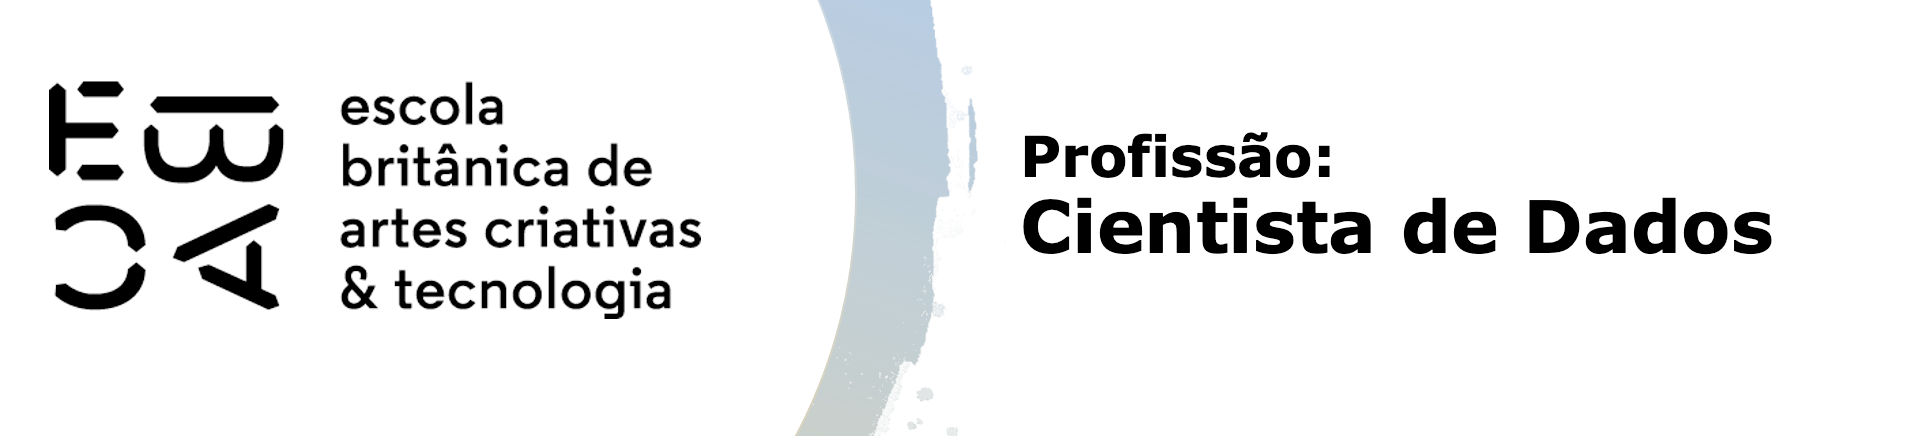

# Tarefa

Neste exercício vamos usar a base [online shoppers purchase intention](https://archive.ics.uci.edu/ml/datasets/Online+Shoppers+Purchasing+Intention+Dataset) de Sakar, C.O., Polat, S.O., Katircioglu, M. et al. Neural Comput & Applic (2018). [Web Link](https://doi.org/10.1007/s00521-018-3523-0).

A base trata de registros de 12.330 sessões de acesso a páginas, cada sessão sendo de um único usuário em um período de 12 meses, para posteriormente estudarmos a relação entre o design da página e o perfil do cliente - "Será que clientes com comportamento de navegação diferentes possuem propensão a compra diferente?" 

Nosso objetivo é tentar agrupar os clientes conforme seu comportamento de navegação entre páginas administrativas, informativas e de produtos. 

As variáveis estão descritas abaixo (em tradução livre do link indicado).

Por este motivo, o escopo desta análise estará fechado nas primeiras seis variáveis da tabela, referentes a quantidade e tempo de acesso por tipo de página, atributos que falam mais do comportamento de navegação do cliente que de características da página o da época do ano.

|Variavel                |Descrição          | 
|------------------------|:-------------------| 
|Administrative          | Quantidade de acessos em páginas administrativas| 
|Administrative_Duration | Tempo de acesso em páginas administrativas | 
|Informational           | Quantidade de acessos em páginas informativas  | 
|Informational_Duration  | Tempo de acesso em páginas informativas  | 
|ProductRelated          | Quantidade de acessos em páginas de produtos | 
|ProductRelated_Duration | Tempo de acesso em páginas de produtos | 
|BounceRates             | *Percentual de visitantes que entram no site e saem sem acionar outros *requests* durante a sessão  | 
|ExitRates               | * Soma de vezes que a página é visualizada por último em uma sessão dividido pelo total de visualizações | 
|PageValues              | * Representa o valor médio de uma página da Web que um usuário visitou antes de concluir uma transação de comércio eletrônico | 
|SpecialDay              | Indica a proximidade a uma data festiva (dia das mães etc) | 
|Month                   | Mês  | 
|OperatingSystems        | Sistema operacional do visitante | 
|Browser                 | Browser do visitante | 
|Region                  | Região | 
|TrafficType             | Tipo de tráfego                  | 
|VisitorType             | Tipo de visitante: novo ou recorrente | 
|Weekend                 | Indica final de semana | 
|Revenue                 | Indica se houve compra ou não |

\* variávels calculadas pelo google analytics

In [1]:
# Importa as bibliotecas necessárias para análise de dados e visualização
import pandas as pd                # Manipulação de dados em DataFrames
import matplotlib.pyplot as plt    # Criação de gráficos
import seaborn as sns              # Visualização de dados estatísticos
import numpy as np                 # Operações numéricas e manipulação de arrays

from sklearn.decomposition import PCA  # Análise de Componentes Principais
from sklearn.preprocessing import StandardScaler  # Normalização de dados
from sklearn.cluster import KMeans  # Algoritmo de agrupamento K-Means
from sklearn.metrics import silhouette_score # Métrica de avaliação de agrupamentos

# Importa função para buscar datasets do repositório UCI Machine Learning
from ucimlrepo import fetch_ucirepo

In [2]:
# Busca o dataset "Online Shoppers Purchasing Intention" do repositório UCI
online_shoppers_purchasing_intention_dataset = fetch_ucirepo(id=468) 

# Extrai as features (variáveis explicativas) como um DataFrame do pandas
X = online_shoppers_purchasing_intention_dataset.data.features 

# Extrai o target (variável resposta) como um DataFrame do pandas
y = online_shoppers_purchasing_intention_dataset.data.targets 

In [3]:
# Exibe os metadados do dataset, como nome, número de instâncias, número de variáveis, descrição, etc.
print(online_shoppers_purchasing_intention_dataset.metadata) 

# Exibe informações detalhadas sobre as variáveis do dataset, como nome, tipo, papel e descrição.
print(online_shoppers_purchasing_intention_dataset.variables) 

{'uci_id': 468, 'name': 'Online Shoppers Purchasing Intention Dataset', 'repository_url': 'https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/468/data.csv', 'abstract': 'Of the 12,330 sessions in the dataset,\n84.5% (10,422) were negative class samples that did not\nend with shopping, and the rest (1908) were positive class\nsamples ending with shopping.', 'area': 'Business', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 12330, 'num_features': 17, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Revenue'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2018, 'last_updated': 'Thu Jan 11 2024', 'dataset_doi': '10.24432/C5F88Q', 'creators': ['C. Sakar', 'Yomi Kastro'], 'intro_paper': {'ID': 367, 'type': 'NATIVE', 'title': 'Real-time prediction of online shoppers’ pur

In [4]:
# Concatena as variáveis explicativas (X) e a variável resposta (y) em um único DataFrame chamado df
df = pd.concat([X, y], axis=1)

# Exibe a contagem de valores únicos na coluna 'Revenue', incluindo valores ausentes (se houver)
df.Revenue.value_counts(dropna=False)

Revenue
False    10422
True      1908
Name: count, dtype: int64

## Análise descritiva

Faça uma análise descritiva das variáveis do escopo.

- Verifique a distribuição dessas variáveis
- Veja se há valores *missing* e caso haja, decida o que fazer
- Faça mais algum tratamento nas variáveis caso ache pertinente

In [5]:
df.columns.nunique()

18

In [6]:
df.isna().sum()  # Verifica a quantidade de valores ausentes em cada coluna do DataFrame

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [7]:
numeracao_meses = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'June': 6,
                   'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}

tipo_de_visitante = {'Returning_Visitor': 1, 'New_Visitor': 2, 'Other': 3}

df1 = df.copy()  # Cria uma cópia do DataFrame original para evitar alterações indesejadas

df1['Month'] = df1['Month'].map(numeracao_meses)  # Mapeia os meses para números inteiros
df1['VisitorType'] = df1['VisitorType'].map(tipo_de_visitante)  # Mapeia os tipos de visitantes

In [8]:
# Normaliza os dados do DataFrame para média 0 e desvio padrão 1
df1_padrao = StandardScaler().fit_transform(df1)

# Ajusta o modelo PCA para 18 componentes principais usando os dados padronizados
prcomp = PCA(n_components=18).fit(df1_padrao)


# Aplica a transformação PCA aos dados normalizados, reduzindo a dimensionalidade
df_pca = prcomp.transform(df1_padrao)

In [9]:
# Função para plotar o scree plot e determinar o número ideal de componentes principais
def screeplot(princomp, ncomp=0, varexplicada=0, criterio=1):

    # Define o critério para o número de componentes principais a ser destacado
    if ncomp > 0:
        ncomp_crit = ncomp  # Usa o número de componentes informado pelo usuário
    elif varexplicada > 0:
        # Calcula o número de componentes necessários para atingir a variância explicada desejada
        ncomp_crit = (
            princomp.explained_variance_ratio_.cumsum() < varexplicada
        ).sum() + 1
    # Critério 1: autovalor padronizado > 1
    elif criterio == 1:
        ncomp_crit = (
            princomp.explained_variance_ratio_ > 1 / princomp.n_components_
        ).sum()
    else:
        ncomp_crit = None  # Não define nenhum critério

    # Cria uma grade de subplots para os gráficos
    fig, ax = plt.subplots(2, 2, sharex=True, figsize=(14, 8))
    plt.subplots_adjust(hspace=0, wspace=0.15)

    # Eixo X: número dos componentes principais
    num_componentes = np.arange(princomp.n_components_) + 1

    # Gráfico da variância explicada por componente
    ax[0, 0].plot(
        num_componentes,
        princomp.explained_variance_,
        "o-",
        linewidth=2,
        color="blue",
        markersize=2,
        alpha=0.2,
    )
    ax[0, 0].set_title("Scree Plot - Variância total")
    ax[0, 0].set_xlabel("Número de componentes")
    ax[0, 0].set_ylabel("Variancia explicada (Autovalores)")

    # Gráfico da variância explicada acumulada
    ax[1, 0].plot(
        num_componentes,
        princomp.explained_variance_.cumsum(),
        "o-",
        linewidth=2,
        color="blue",
        markersize=2,
        alpha=0.2,
    )
    ax[1, 0].set_xlabel("Número de componentes")
    ax[1, 0].set_ylabel("Variancia explicada (Acumulada)")

    # Gráfico da variância percentual explicada por componente
    ax[0, 1].plot(
        num_componentes,
        princomp.explained_variance_ratio_,
        "o-",
        linewidth=2,
        color="blue",
        markersize=2,
        alpha=0.2,
    )
    ax[0, 1].set_title("Scree Plot - Variância percentual")
    ax[0, 1].set_xlabel("Número de componentes")
    ax[0, 1].set_ylabel("Variancia explicada (percentual)")

    # Gráfico da variância percentual acumulada
    ax[1, 1].plot(
        num_componentes,
        princomp.explained_variance_ratio_.cumsum(),
        "o-",
        linewidth=2,
        color="blue",
        markersize=2,
        alpha=0.2,
    )
    ax[1, 1].set_xlabel("Número de componentes")
    ax[1, 1].set_ylabel("Variancia explicada (% Acumulado)")

    if ncomp_crit != None:
        # Linhas verticais de referência para o número de componentes escolhido
        ax[0, 0].axvline(x=ncomp_crit, color="r", linestyle="-", linewidth=0.5)
        ax[1, 1].axvline(x=ncomp_crit, color="r", linestyle="-", linewidth=0.5)
        ax[1, 0].axvline(x=ncomp_crit, color="r", linestyle="-", linewidth=0.5)
        ax[0, 1].axvline(x=ncomp_crit, color="r", linestyle="-", linewidth=0.5)

        # Linhas horizontais de referência para os valores correspondentes ao componente escolhido
        variancia = princomp.explained_variance_[ncomp_crit - 1]
        variancia_acumulada = princomp.explained_variance_.cumsum()[ncomp_crit - 1]
        pct_variancia = princomp.explained_variance_ratio_[ncomp_crit - 1]
        pct_variancia_acumulada = princomp.explained_variance_ratio_.cumsum()[
            ncomp_crit - 1
        ]

        ax[0, 0].axhline(y=variancia, color="r", linestyle="-", linewidth=0.5)
        ax[1, 0].axhline(y=variancia_acumulada, color="r", linestyle="-", linewidth=0.5)
        ax[0, 1].axhline(y=pct_variancia, color="r", linestyle="-", linewidth=0.5)
        ax[1, 1].axhline(
            y=pct_variancia_acumulada, color="r", linestyle="-", linewidth=0.5
        )

    # Exibe informações sobre o número de componentes e variância explicada
    print(f"Número de componentes:............... {ncomp_crit}")
    print(f"Variância da ultima CP:.............. {variancia:.2f}")
    print(f"Variância total explicada:........... {variancia_acumulada:.2f}")
    print(f"Variância percentual da última CP:... {100*pct_variancia:.2f}%")
    print(f"Variância percentual total explicada: {100*pct_variancia_acumulada:.2f}%")
    plt.show()
    return ncomp_crit


In [10]:
df_pca = pd.DataFrame(df_pca, columns=[f'PC{i+1}' for i in range(18)])  # Cria um DataFrame com os componentes principais

Número de componentes:............... 13
Variância da ultima CP:.............. 0.67
Variância total explicada:........... 16.53
Variância percentual da última CP:... 3.72%
Variância percentual total explicada: 91.85%


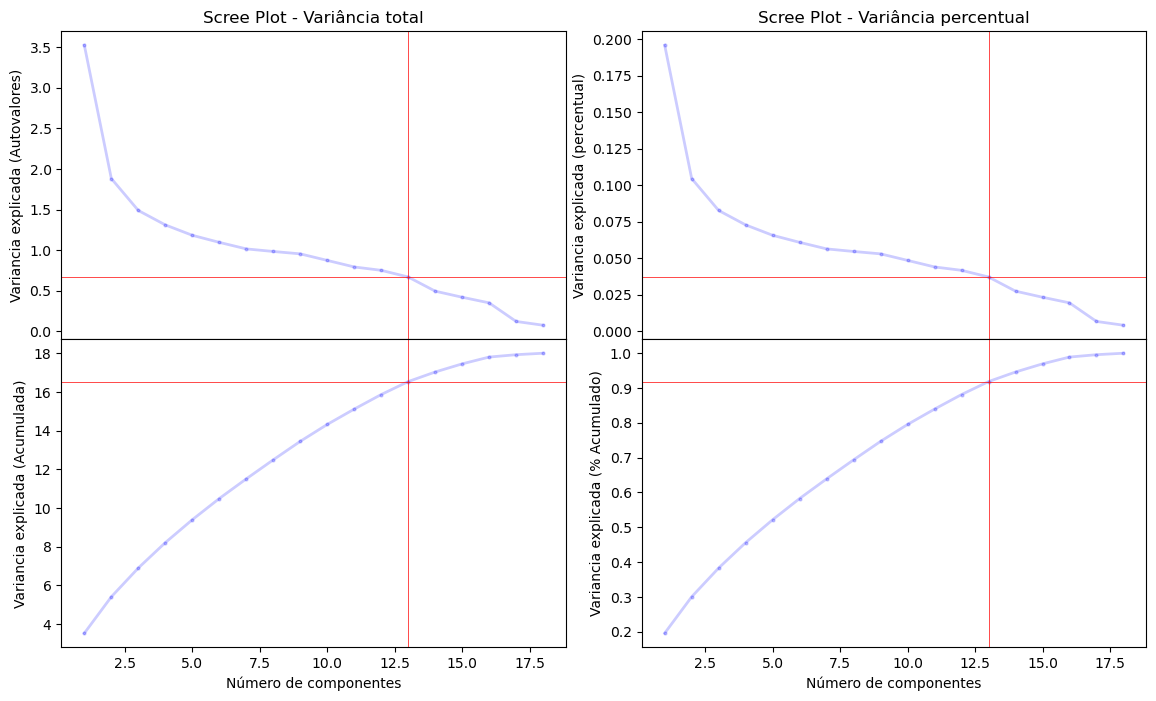

13

In [11]:
screeplot(prcomp, varexplicada=0.90)  # Chama a função screeplot para visualizar a variância explicada pelos componentes principais

## Número de grupos

Utilize as técnicas vistas em aula que te ajudem a decidir pelo número de grupos a ser utilizados.

In [12]:
silhuette_scores_pca = []  # Lista para armazenar os scores de silhueta de cada solução de agrupamento
max_clusters = 10      # Número máximo de clusters a ser testado
dict_grupos_pca = {}       # Dicionário para armazenar os rótulos dos grupos como categorias nomeadas

# Loop para testar diferentes quantidades de clusters (de 2 até max_clusters)
for n_clusters in range(2, max_clusters + 1):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)  # Instancia o modelo KMeans
    kmeans.fit(df_pca)  # Ajusta o modelo aos dados transformados pelo PCA
    silhuette_scores_pca.append(silhouette_score(df_pca, kmeans.labels_))  # Calcula e armazena o índice de silhueta
    nomes_grupos = [f'Grupo_{i}' for i in range(n_clusters)]  # Cria nomes para os grupos (ex: Grupo_0, Grupo_1, ...)
    df_pca[f'Grupo_{n_clusters}'] = kmeans.labels_  # Adiciona ao DataFrame os rótulos dos grupos (como números)
    # Adiciona ao dicionário os rótulos dos grupos como categorias nomeadas (ex: 'Grupo_0', 'Grupo_1', ...)
    dict_grupos_pca[f'Grupo_{n_clusters}'] = pd.Categorical.from_codes(kmeans.labels_, categories=nomes_grupos)

# Cria uma cópia do DataFrame com os componentes principais
df_pca1 = df_pca.copy()
# Substitui as colunas de grupos numéricos por categorias nomeadas no novo DataFrame
df_pca1[['Grupo_' + str(x) for x in range(2, max_clusters + 1)]] = pd.DataFrame(dict_grupos_pca)

<Axes: xlabel='n_clusters'>

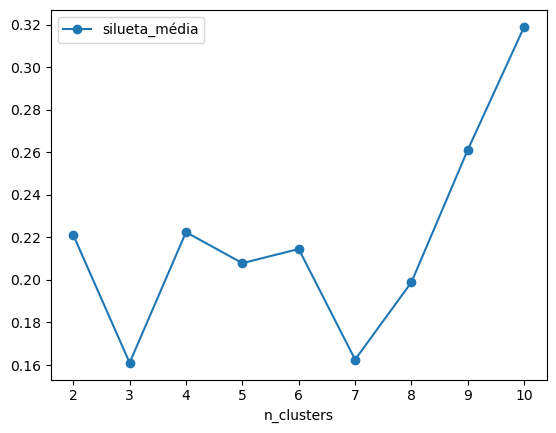

In [13]:
# Cria um DataFrame com o número de clusters testados e os respectivos valores médios do índice de silhueta
df_silueta_pca = pd.DataFrame({'n_clusters': list(range(2, max_clusters+1)), 'silueta_média': silhuette_scores_pca})

# Plota um gráfico de linha mostrando como o índice de silhueta médio varia conforme o número de clusters
df_silueta_pca.plot.line(x='n_clusters', y='silueta_média', marker='o')

In [14]:
df_agrupamento = df1.copy()  # Cria uma cópia do DataFrame original para armazenar os resultados do agrupamento

silhuette_scores = []  # Lista para armazenar os scores de silhueta de cada solução de agrupamento
max_clusters = 10      # Número máximo de clusters a ser testado

# Loop para testar diferentes quantidades de clusters (de 2 até max_clusters)
for n_clusters in range(2, max_clusters + 1):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)  # Instancia o modelo KMeans
    kmeans.fit(df1)  # Ajusta o modelo aos dados transformados pelo PCA
    silhuette_scores.append(silhouette_score(df1, kmeans.labels_))  # Calcula e armazena o índice de silhueta
    nomes_grupos = [f'Grupo_{i}' for i in range(n_clusters)]  # Cria nomes para os grupos (ex: Grupo_0, Grupo_1, ...)
    # Adiciona ao dicionário os rótulos dos grupos como categorias nomeadas (ex: 'Grupo_0', 'Grupo_1', ...)
    df_agrupamento[f'Grupo_{n_clusters}'] = pd.Categorical.from_codes(kmeans.labels_, categories=nomes_grupos)

<Axes: xlabel='n_clusters'>

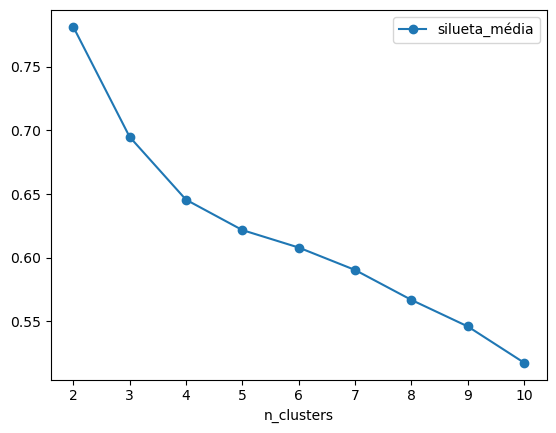

In [16]:
# Cria um DataFrame com o número de clusters testados e os respectivos valores médios do índice de silhueta
df_silueta_agrupamento = pd.DataFrame({'n_clusters': list(range(2, max_clusters+1)), 'silueta_média': silhuette_scores})

# Plota um gráfico de linha mostrando como o índice de silhueta médio varia conforme o número de clusters
df_silueta_agrupamento.plot.line(x='n_clusters', y='silueta_média', marker='o')

Observação: O método de Análise de Componentes Principais (PCA) foi inicialmente aplicado com o objetivo de reduzir a dimensionalidade dos dados e concentrar a variabilidade em um número menor de componentes. No entanto, para a tarefa de definição de clusters e considerando o conjunto de dados atual, a aplicação do PCA se mostrou pouco eficaz. Diante disso, optou-se por prosseguir a análise de agrupamento utilizando os dados em sua forma original, sem transformação.

## Avaliação dos grupos

Faça uma análise descritiva para pelo menos duas soluções de agrupamentos (duas quantidades diferentes de grupos) sugeridas no item anterior, utilizando as variáveis que estão no escopo do agrupamento.
- Com base nesta análise e nas análises anteriores, decida pelo agrupamento final. 
- Se puder, sugira nomes para os grupos.

In [17]:
# Define opções de exibição do pandas para mostrar todas as colunas e não truncar o conteúdo das células
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

# Função para plotar a proporção de cada categoria de uma coluna do DataFrame
def plotar_proporcao(coluna: str, df=df_agrupamento):
    # Calcula a proporção (%) de cada grupo na coluna selecionada
    proporcao = df[coluna].value_counts(normalize=True) * 100
    # Plota um gráfico de barras das proporções
    proporcao.plot(kind="bar", color="skyblue")

    # Adiciona o valor percentual acima de cada barra do gráfico
    for i, valor in enumerate(proporcao):
        plt.text(i, valor + 0.5, f"{valor:.2f}%", ha="center", va="bottom", fontsize=10)

    plt.title(f"Proporção dos grupos em {coluna}")  # Define o título do gráfico
    plt.xlabel("Grupos")                            # Rótulo do eixo X
    plt.ylabel("Proporção (%)")                     # Rótulo do eixo Y
    plt.xticks(rotation=45)                         # Rotaciona os rótulos do eixo X para melhor visualização
    plt.show()                                      # Exibe o gráfico
    
    
def relacao_variaveis_x(grupo: int, coluna: str, df=df_agrupamento):
    # Plota gráfico de barras mostrando a média da variável 'coluna' por cluster e por Revenue
    ax = sns.barplot(
        data=df_agrupamento,
        x='Grupo_'+str(grupo),
        y=coluna,
        hue='Revenue',
        ci=None,
        palette='coolwarm',
    )

    # Adiciona os valores no topo de cada barra
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', label_type='edge', fontsize=10)

    plt.title(f"Média de '{coluna}' por Cluster e Revenue")  # Título do gráfico
    plt.ylabel(f"Média de {coluna}")                         # Rótulo do eixo Y
    plt.xlabel(f"Cluster (Grupo_{grupo})")                   # Rótulo do eixo X
    plt.xticks(rotation=0)                                   # Mantém os rótulos do eixo X na horizontal
    plt.tight_layout()                                       # Ajusta o layout para não sobrepor elementos
    plt.show()                                               # Exibe o gráfico


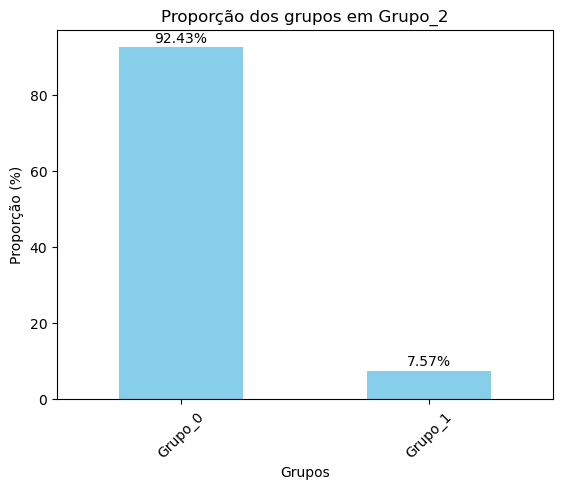

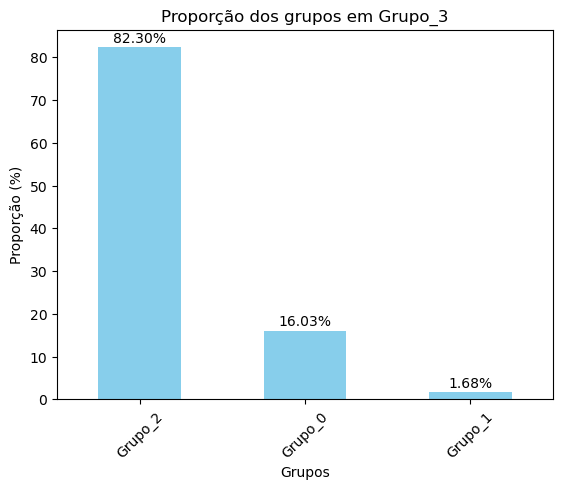

In [18]:
# Plota a proporção (%) de cada grupo na solução de 2 clusters ('Grupo_2')
plotar_proporcao(coluna='Grupo_2')

# Plota a proporção (%) de cada grupo na solução de 3 clusters ('Grupo_3')
plotar_proporcao(coluna='Grupo_3')

C:\Users\hfasa\AppData\Local\Temp\ipykernel_11180\3124458458.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(


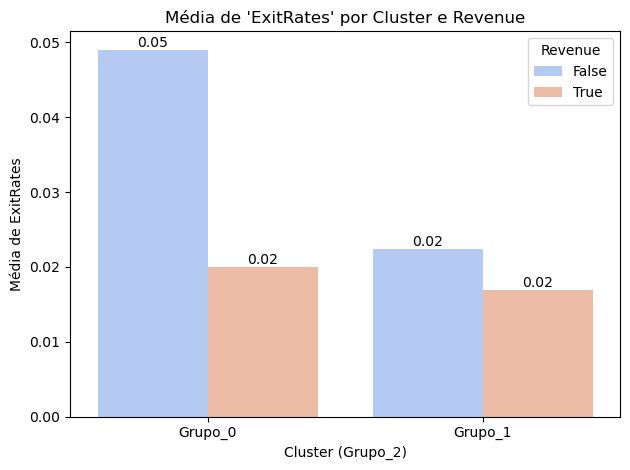

C:\Users\hfasa\AppData\Local\Temp\ipykernel_11180\3124458458.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(


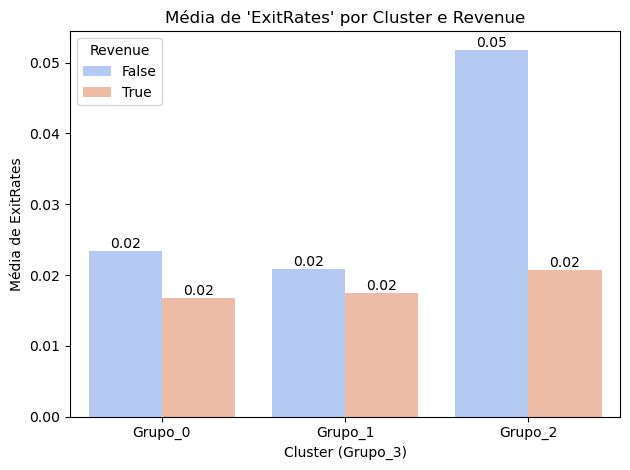

In [19]:
# Plota gráfico de barras mostrando a média da variável 'ExitRates' por cluster (Grupo_2) e por Revenue
relacao_variaveis_x(2, 'ExitRates')  # Exibe o gráfico

# Plota gráfico de barras mostrando a média da variável 'ExitRates' por cluster (Grupo_3) e por Revenue
relacao_variaveis_x(3, 'ExitRates')  # Exibe o gráfico

C:\Users\hfasa\AppData\Local\Temp\ipykernel_11180\3124458458.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(


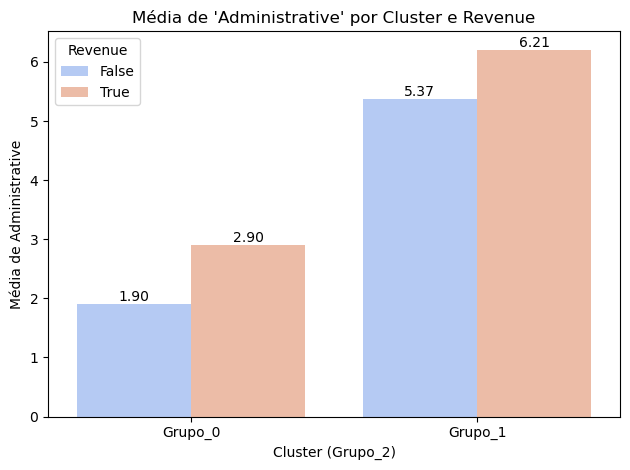

C:\Users\hfasa\AppData\Local\Temp\ipykernel_11180\3124458458.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(


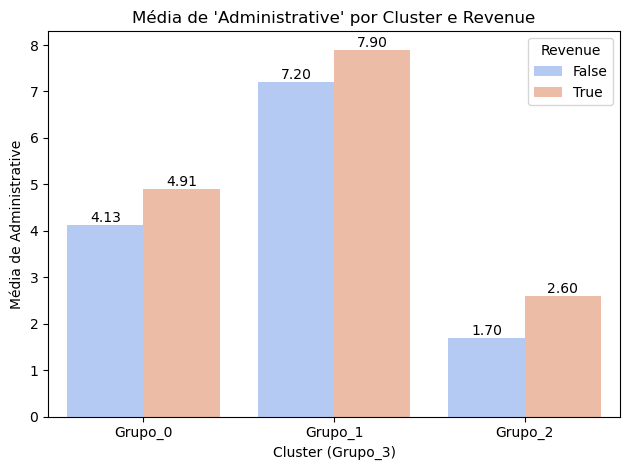

In [20]:
# Plota gráfico de barras mostrando a média da variável 'Administrative' por cluster (Grupo_2) e por Revenue
relacao_variaveis_x(2, 'Administrative')  # Exibe o gráfico

# Plota gráfico de barras mostrando a média da variável 'Administrative' por cluster (Grupo_3) e por Revenue
relacao_variaveis_x(3, 'Administrative')  # Exibe o gráfico

C:\Users\hfasa\AppData\Local\Temp\ipykernel_11180\3124458458.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(


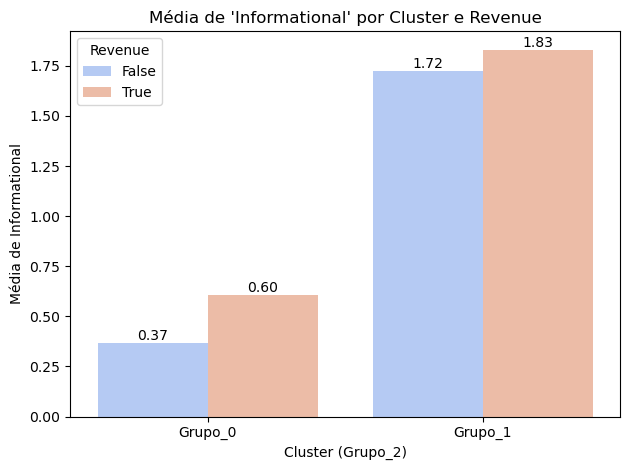

C:\Users\hfasa\AppData\Local\Temp\ipykernel_11180\3124458458.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(


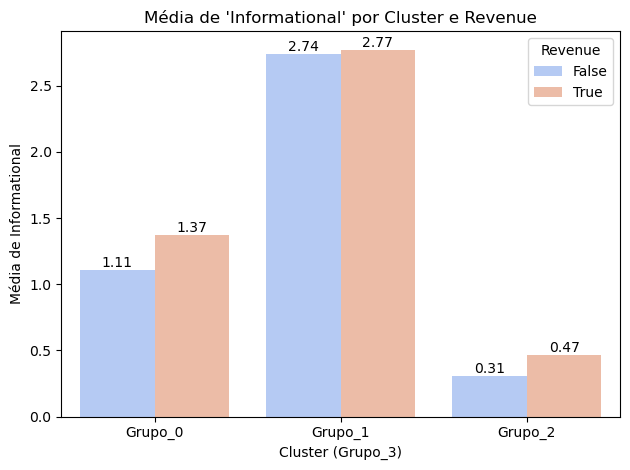

In [21]:
# Plota gráfico de barras mostrando a média da variável 'Informational' por cluster (Grupo_2) e por Revenue
relacao_variaveis_x(2, 'Informational')  # Exibe o gráfico

# Plota gráfico de barras mostrando a média da variável 'Informational' por cluster (Grupo_3) e por Revenue
relacao_variaveis_x(3, 'Informational')  # Exibe o gráfico

C:\Users\hfasa\AppData\Local\Temp\ipykernel_11180\2608758316.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ax = df_agrupamento.groupby(['Grupo_2', 'Revenue']).size().unstack().plot.bar()
C:\Users\hfasa\AppData\Local\Temp\ipykernel_11180\2608758316.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ax = df_agrupamento.groupby(['Grupo_3', 'Revenue']).size().unstack().plot.bar()


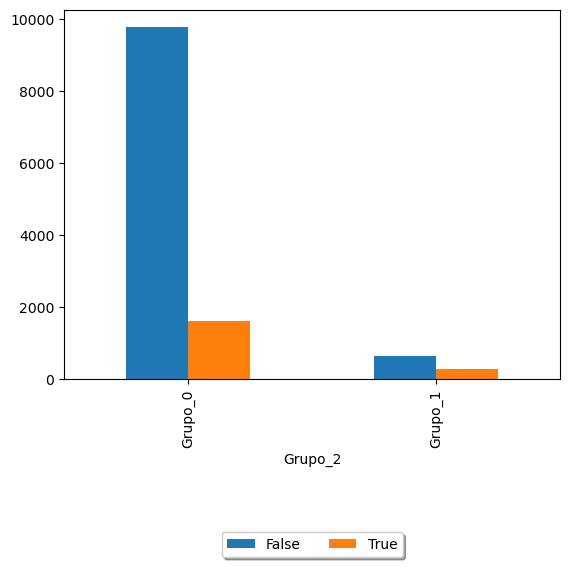

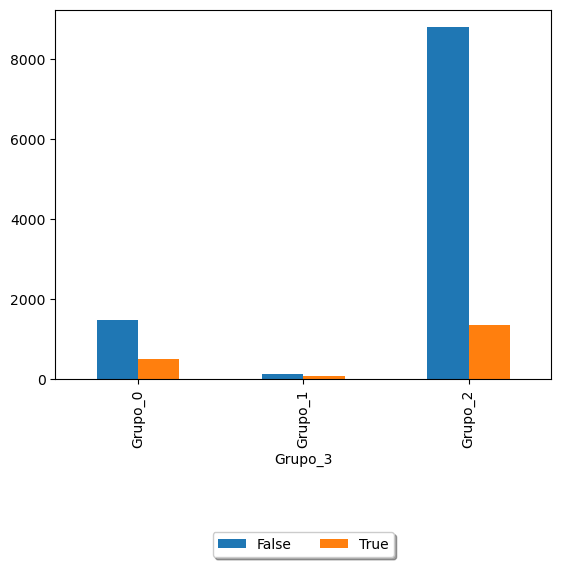

In [22]:
# Agrupa o DataFrame pelos clusters formados com 2 grupos ('Grupo_2') e pela variável 'Revenue'
# Conta o número de ocorrências de cada valor de 'Revenue' em cada grupo
# Usa unstack() para transformar os valores de 'Revenue' em colunas
# Plota um gráfico de barras para visualizar a distribuição de 'Revenue' em cada grupo
ax = df_agrupamento.groupby(['Grupo_2', 'Revenue']).size().unstack().plot.bar()

# Ajusta a legenda do gráfico para ficar centralizada abaixo do gráfico,
# com 3 colunas, caixa estilizada e sombra
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -.5),
          ncol=3, fancybox=True, shadow=True)

# Repete o mesmo processo para os clusters formados com 3 grupos ('Grupo_3')
ax = df_agrupamento.groupby(['Grupo_3', 'Revenue']).size().unstack().plot.bar()

# Ajusta a legenda do gráfico para o segundo gráfico
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -.5),
          ncol=3, fancybox=True, shadow=True)

C:\Users\hfasa\AppData\Local\Temp\ipykernel_11180\3124458458.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(


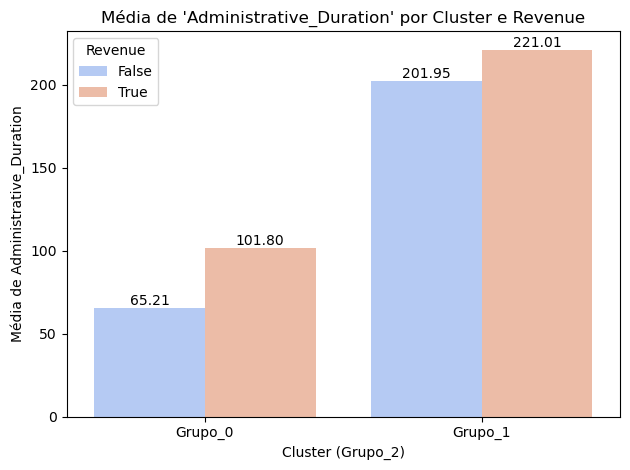

C:\Users\hfasa\AppData\Local\Temp\ipykernel_11180\3124458458.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(


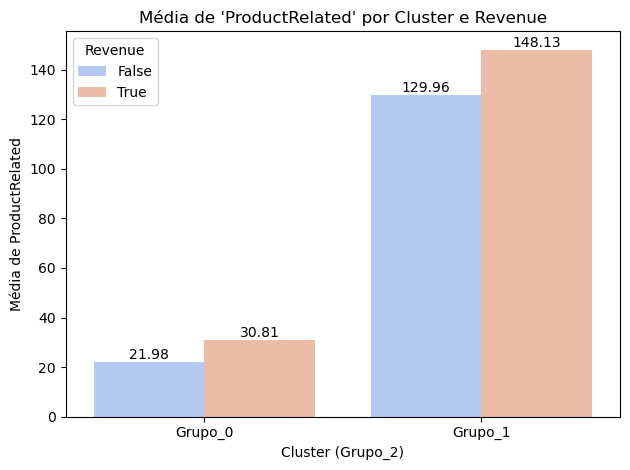

C:\Users\hfasa\AppData\Local\Temp\ipykernel_11180\3124458458.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(


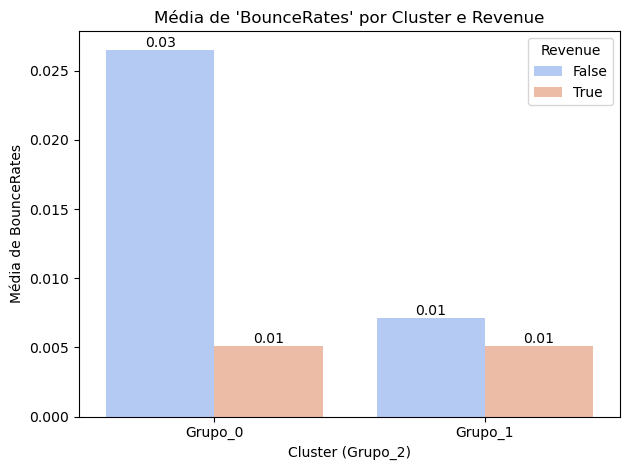

In [23]:
# Plota gráfico de barras mostrando a média da variável 'Administrative_Duration' por cluster (Grupo_2) e por Revenue
relacao_variaveis_x(2, 'Administrative_Duration')  # Exibe o gráfico

# Plota gráfico de barras mostrando a média da variável 'ProductRelated' por cluster (Grupo_2) e por Revenue
relacao_variaveis_x(2, 'ProductRelated')  # Exibe o gráfico

# Plota gráfico de barras mostrando a média da variável 'BounceRates' por cluster (Grupo_2) e por Revenue
relacao_variaveis_x(2, 'BounceRates')  # Exibe o gráfico

In [24]:
df_agrupamento

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,Grupo_2,Grupo_3,Grupo_4,Grupo_5,Grupo_6,Grupo_7,Grupo_8,Grupo_9,Grupo_10
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,2,1,1,1,1,1,False,False,Grupo_0,Grupo_2,Grupo_2,Grupo_2,Grupo_2,Grupo_2,Grupo_2,Grupo_2,Grupo_2
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,2,2,2,1,2,1,False,False,Grupo_0,Grupo_2,Grupo_2,Grupo_2,Grupo_2,Grupo_2,Grupo_2,Grupo_2,Grupo_2
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,2,4,1,9,3,1,False,False,Grupo_0,Grupo_2,Grupo_2,Grupo_2,Grupo_2,Grupo_2,Grupo_2,Grupo_2,Grupo_2
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,2,3,2,2,4,1,False,False,Grupo_0,Grupo_2,Grupo_2,Grupo_2,Grupo_2,Grupo_2,Grupo_2,Grupo_2,Grupo_2
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,2,3,3,1,4,1,True,False,Grupo_0,Grupo_2,Grupo_2,Grupo_2,Grupo_2,Grupo_2,Grupo_2,Grupo_0,Grupo_9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,12,4,6,1,1,1,True,False,Grupo_0,Grupo_2,Grupo_0,Grupo_0,Grupo_0,Grupo_0,Grupo_0,Grupo_7,Grupo_0
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,11,3,2,1,8,1,True,False,Grupo_0,Grupo_2,Grupo_2,Grupo_2,Grupo_2,Grupo_2,Grupo_2,Grupo_2,Grupo_2
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,11,3,2,1,13,1,True,False,Grupo_0,Grupo_2,Grupo_2,Grupo_2,Grupo_2,Grupo_2,Grupo_2,Grupo_2,Grupo_2
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,11,2,2,3,11,1,False,False,Grupo_0,Grupo_2,Grupo_2,Grupo_2,Grupo_2,Grupo_2,Grupo_2,Grupo_2,Grupo_2


## Avaliação de resultados

Avalie os grupos obtidos com relação às variáveis fora do escopo da análise (minimamente *bounce rate* e *revenue*). 
- Qual grupo possui clientes mais propensos à compra?

Resposta: Usuários que acessam mais páginas administrativas e informativas, e que permanecem por mais tempo nelas, apresentam uma maior taxa de conversão em receita. Em contrapartida, usuários com altos valores de Bounce Rate e Exit Rate demonstram um comportamento oposto, indicando menor interesse ou engajamento com o conteúdo, e consequentemente, menor propensão à conversão. Claramente estes comportamentos estão refletidos nos grupos, sendo mais presente no Grupo_0 um volume significativo de usuários relacionados ao índice de Bounce rate e Exit Rate, sendo o inverso para os componentes do Grupo_1"